# 03 — Competitive Benchmarking

Cluster hotels into comparable peer groups using K-Means on multi-dimensional rating profiles, then identify under-performers and generate actionable recommendations.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "src").exists():
    sys.path.insert(0, str(PROJECT_ROOT))
else:
    PROJECT_ROOT = PROJECT_ROOT.parent
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import *
from src.benchmarking import (
    compute_hotel_features,
    cluster_hotels,
    find_optimal_k,
    analyze_group_performance,
    generate_recommendations,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120


REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

## 3.1 Compute Hotel Features

In [2]:
features = compute_hotel_features(min_reviews=10)
print(f"Hotels with ≥10 reviews: {len(features):,}")
features.describe().round(2)

Hotels with ≥10 reviews: 251


,review_count,avg_rating_overall,avg_rating_service,avg_rating_cleanliness,avg_rating_value,avg_rating_location,avg_rating_sleep_quality,avg_rating_rooms,avg_text_length,mobile_ratio,avg_sentiment_polarity,pct_luxury_mentions,pct_budget_mentions,pct_business_mentions
count,251.00,251.00,251.00,251.00,251.00,251.00,251.00,251.00,251.00,251.00,251.00,251.0,251.0,251.0
mean,378.30,3.74,3.44,3.58,3.33,3.54,2.61,3.05,802.58,0.06,0.20,0.0,0.0,0.0
std,474.65,0.50,0.66,0.68,0.61,0.59,0.81,0.67,108.57,0.03,0.06,0.0,0.0,0.0
min,50.00,1.71,1.31,1.21,0.05,0.06,0.03,0.99,378.68,0.00,0.03,0.0,0.0,0.0
25%,112.50,3.51,3.08,3.26,3.06,3.29,2.10,2.66,737.05,0.04,0.16,0.0,0.0,0.0
50%,226.00,3.75,3.53,3.71,3.43,3.64,2.65,3.12,794.74,0.06,0.20,0.0,0.0,0.0
75%,422.50,4.02,3.93,4.08,3.77,3.96,3.21,3.52,863.52,0.08,0.25,0.0,0.0,0.0
max,3312.00,4.79,4.47,4.71,4.38,4.68,4.11,4.43,1270.84,0.19,0.31,0.0,0.0,0.0


## 3.2 Find Optimal Number of Clusters

/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

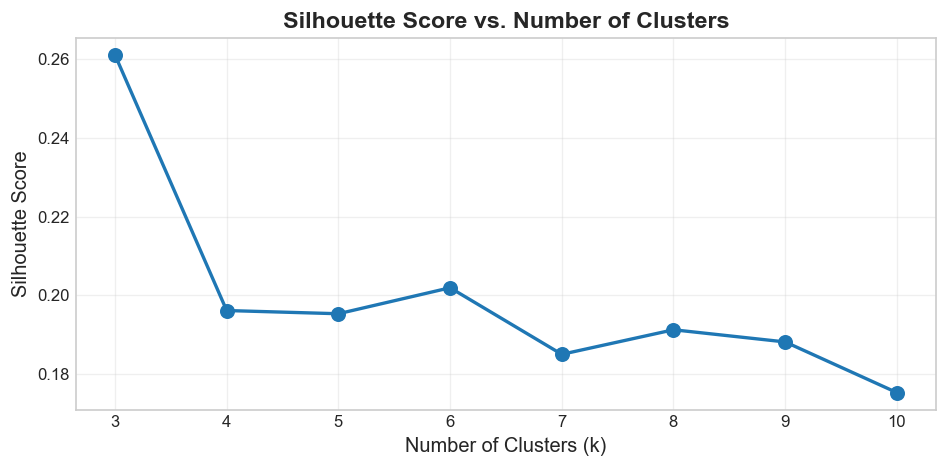

Business overridden k = 4


In [3]:
scores = find_optimal_k(features, k_range=range(3, 11))

plt.figure(figsize=(8, 4))
plt.plot(list(scores.keys()), list(scores.values()), "o-", linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score vs. Number of Clusters", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "silhouette_scores.png"), bbox_inches="tight")
plt.show()

# NOTE: While silhouette score might peak at k=3, business requirements dictate 
# a 4-tier classification (Luxury, High-end, Mid-range, Economy). 
# Therefore, we will manually override best_k to 4 for subsequent analysis.
best_k = 4
print(f"Business overridden k = {best_k}")

## 3.3 Perform Clustering

In [4]:
df_clustered, sil_score, km_model, scaler = cluster_hotels(features, n_clusters=best_k)

# We update labels to 4-tier
from src.benchmarking import assign_cluster_labels
tier_labels = assign_cluster_labels(df_clustered)
df_clustered["segment_name"] = df_clustered["cluster"].map(tier_labels)

print(f"Silhouette score (for k={best_k}): {sil_score:.4f}")
print("\nCluster sizes:")
print(df_clustered["segment_name"].value_counts())


Silhouette score (for k=4): 0.1962

Cluster sizes:
segment_name
High-end     82
Mid-range    73
Luxury       63
Economy      33
Name: count, dtype: int64


/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/is5126/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 3.4 Cluster Profile — Radar Chart

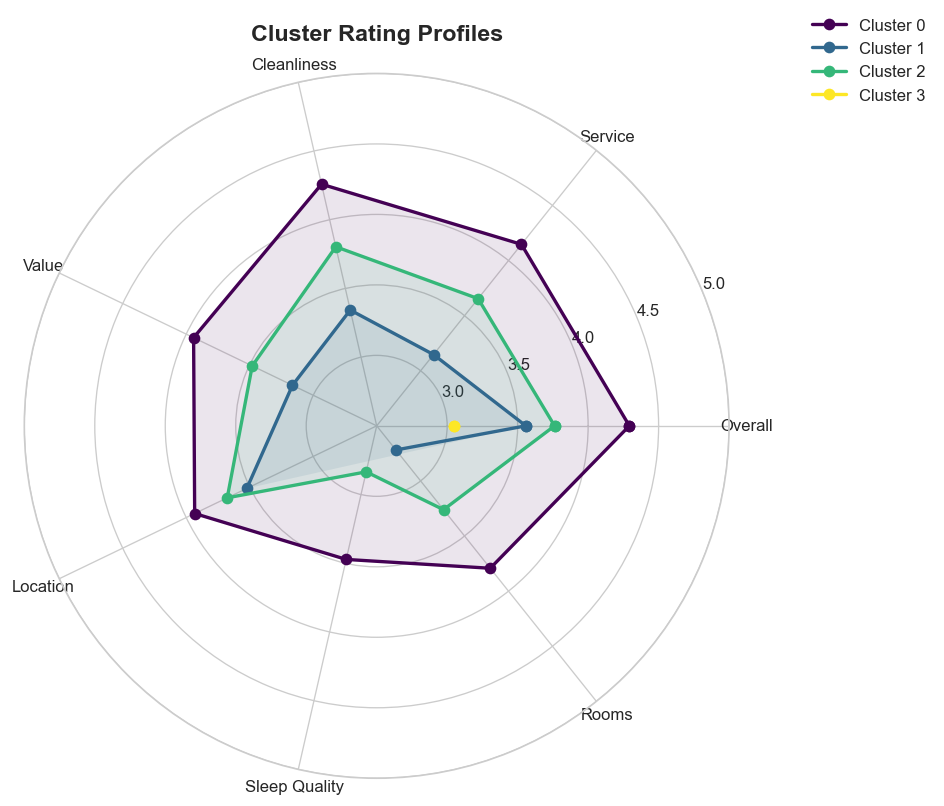

In [5]:
import matplotlib.pyplot as plt
import numpy as np

rating_cols = [c for c in df_clustered.columns if c.startswith("avg_rating_")]
cluster_means = df_clustered.groupby("cluster")[rating_cols].mean()
labels_short = [c.replace("avg_rating_", "").replace("_", " ").title() for c in rating_cols]

angles = np.linspace(0, 2 * np.pi, len(rating_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.viridis(np.linspace(0, 1, len(cluster_means)))
for idx, (cluster_id, row) in enumerate(cluster_means.iterrows()):
    values = row.tolist() + [row.iloc[0]]
    ax.plot(angles, values, "o-", linewidth=2, label=f"Cluster {cluster_id}", color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])
ax.set_thetagrids(np.degrees(angles[:-1]), labels_short, fontsize=10)
ax.set_ylim(2.5, 5)
ax.set_title("Cluster Rating Profiles", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "cluster_radar.png"), bbox_inches="tight")
plt.show()

## 3.5 Group Performance Summary

In [6]:
summary = analyze_group_performance(df_clustered)
summary

,num_hotels,avg_reviews,avg_rating_overall,avg_rating_service,avg_rating_cleanliness,avg_rating_value,avg_rating_location,avg_rating_sleep_quality,avg_rating_rooms
cluster,,,,,,,,,
0,63,257.81,4.29,4.15,4.26,3.94,3.93,3.47,3.79
1,73,659.38,3.56,3.15,3.34,3.16,3.52,2.18,2.72
2,82,185.29,3.76,3.65,3.80,3.48,3.68,2.83,3.26
3,33,466.12,3.05,2.23,2.28,2.19,2.50,1.36,1.86


## 3.6 Scatter: Overall vs Service by Cluster

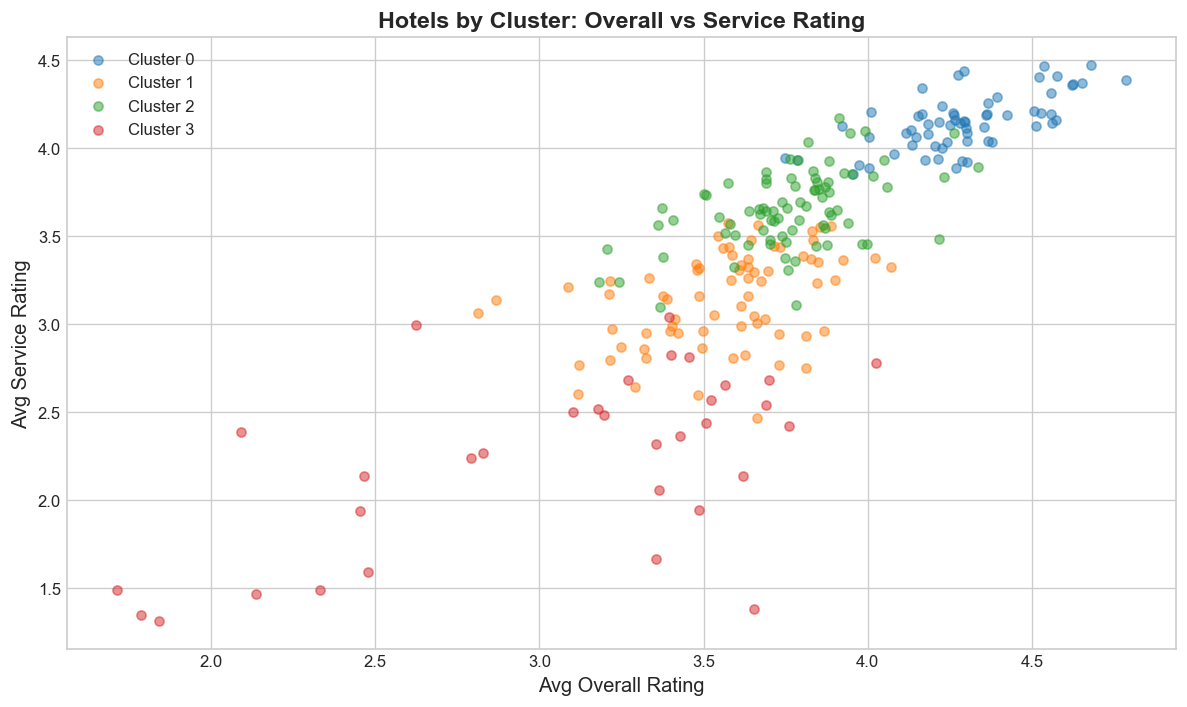

In [7]:
plt.figure(figsize=(10, 6))
for cid in sorted(df_clustered["cluster"].unique()):
    subset = df_clustered[df_clustered["cluster"] == cid]
    plt.scatter(subset["avg_rating_overall"], subset["avg_rating_service"],
                alpha=0.5, label=f"Cluster {cid}", s=30)
plt.xlabel("Avg Overall Rating", fontsize=12)
plt.ylabel("Avg Service Rating", fontsize=12)
plt.title("Hotels by Cluster: Overall vs Service Rating", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "cluster_scatter.png"), bbox_inches="tight")
plt.show()

## 3.7 Recommendations for Under-Performers

In [8]:
recs = generate_recommendations(df_clustered, top_n=20)
print(f"Hotels with improvement opportunities: {len(recs)}")
recs.head(20)

Hotels with improvement opportunities: 128


,hotel_id,cluster,overall_rating,biggest_weakness,gap_vs_peers,num_weak_dimensions,recommendation
124,616735,3,3.653183,Location,2.43,6,Focus on improving Location (gap of 2.43 vs pe...
125,673661,3,1.712900,Overall,1.33,5,Focus on improving Overall (gap of 1.33 vs pee...
116,99287,3,1.786078,Overall,1.26,7,Focus on improving Overall (gap of 1.26 vs pee...
123,267183,3,1.841005,Overall,1.21,7,Focus on improving Overall (gap of 1.21 vs pee...
10,112053,0,4.303737,Sleep Quality,1.20,2,Focus on improving Sleep Quality (gap of 1.20 ...
62,260396,1,2.869029,Sleep Quality,1.18,2,Focus on improving Sleep Quality (gap of 1.18 ...
24,1236696,0,4.251151,Sleep Quality,1.18,2,Focus on improving Sleep Quality (gap of 1.18 ...
53,121981,1,3.626295,Sleep Quality,1.09,3,Focus on improving Sleep Quality (gap of 1.09 ...
21,665163,0,4.131190,Sleep Quality,1.09,3,Focus on improving Sleep Quality (gap of 1.09 ...
114,93356,3,2.089826,Overall,0.96,3,Focus on improving Overall (gap of 0.96 vs pee...


## 3.8 Validation

We validate the clustering approach via the silhouette score (reported above). A score above 0.25 generally indicates reasonable cluster structure.

In [9]:
print(f"Final silhouette score: {sil_score:.4f}")
if sil_score > 0.25:
    print("→ Clustering has reasonable structure — peer groups are meaningful.")
else:
    print("→ Consider adjusting features or k for better separation.")
print("Benchmarking complete ✓")

Final silhouette score: 0.1962
→ Consider adjusting features or k for better separation.
Benchmarking complete ✓
